In [3]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
DATASET_DIR = "/mnt/e/kartik/Mango flower disease detection DL project/mango_dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
BALANCED_TRAIN_DIR = os.path.join(DATASET_DIR, "train_balanced")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")
MODEL_DIR = os.path.join(DATASET_DIR, "models")

os.makedirs(MODEL_DIR, exist_ok=True)

print("Dataset:", DATASET_DIR)
print("Train:", TRAIN_DIR)
print("Balanced train:", BALANCED_TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)
print("Models:", MODEL_DIR)

Dataset: /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset
Train: /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/train
Balanced train: /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/train_balanced
Validation: /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/validation
Test: /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/test
Models: /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models


In [6]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    BALANCED_TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

validation_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Found 1400 files belonging to 7 classes.


W0000 00:00:1790102878.465878    1835 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790102878.663644    1835 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5233 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Found 139 files belonging to 7 classes.
Found 151 files belonging to 7 classes.
Classes:
0 : anthracnose
1 : anthracnose & mango malformation
2 : anthracnose & powdery mildew
3 : healthy
4 : mango malformation
5 : mango malformation & powdery mildew
6 : powdery mildew


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
validation_ds = validation_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.10)
], name="data_augmentation")

In [9]:
base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(256, 256, 3)
)

base_model.trainable = False

print("EfficientNetV2B0 loaded.")
print("Total backbone layers:", len(base_model.layers))

EfficientNetV2B0 loaded.
Total backbone layers: 270


In [10]:
model = keras.Sequential([
    keras.Input(shape=(256, 256, 3)),

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.30),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.20),

    layers.Dense(7, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,084,183 (23.21 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [12]:
checkpoint_path = os.path.join(
    MODEL_DIR,
    "experiment_A_baseline_best.keras"
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [16]:
history_A = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=12,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/12


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8757 - loss: 0.3683 
Epoch 1: val_loss improved from 0.64265 to 0.60222, saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras

Epoch 1: finished saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.8757 - loss: 0.3683 - val_accuracy: 0.7986 - val_loss: 0.6022 - learning_rate: 0.0010
Epoch 2/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.8729 - loss: 0.3535

W0000 00:00:1790103370.257437    4788 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 2: val_loss improved from 0.60222 to 0.57113, saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras

Epoch 2: finished saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 457ms/step - accuracy: 0.8729 - loss: 0.3535 - val_accuracy: 0.7842 - val_loss: 0.5711 - learning_rate: 0.0010
Epoch 3/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8979 - loss: 0.2837
Epoch 3: val_loss improved from 0.57113 to 0.56524, saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras

Epoch 3: finished saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.8979 - loss: 0.2837 - val_accuracy: 0.7842 - val_loss: 0.5652 - learning_ra

W0000 00:00:1790103510.224128    3297 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9193 - loss: 0.2482

W0000 00:00:1790103529.166510    4788 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 5: val_loss improved from 0.54416 to 0.50170, saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras

Epoch 5: finished saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 495ms/step - accuracy: 0.9193 - loss: 0.2477 - val_accuracy: 0.8561 - val_loss: 0.5017 - learning_rate: 0.0010
Epoch 6/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9043 - loss: 0.2562
Epoch 6: val_loss did not improve from 0.50170
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 467ms/step - accuracy: 0.9043 - loss: 0.2562 - val_accuracy: 0.7986 - val_loss: 0.5504 - learning_rate: 0.0010
Epoch 7/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9207 - loss: 0.2285
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 7: val_loss did not improve from 0.50170
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 476ms/step - accu

W0000 00:00:1790103574.760959    3297 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9221 - loss: 0.2086
Epoch 8: val_loss did not improve from 0.50170
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 460ms/step - accuracy: 0.9221 - loss: 0.2086 - val_accuracy: 0.8273 - val_loss: 0.5099 - learning_rate: 2.0000e-04
Epoch 9/12
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9404 - loss: 0.1833
Epoch 9: val_loss improved from 0.50170 to 0.49471, saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras

Epoch 9: finished saving model to /mnt/e/kartik/Mango flower disease detection DL project/mango_dataset/models/experiment_A_baseline_best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 501ms/step - accuracy: 0.9407 - loss: 0.1824 - val_accuracy: 0.8345 - val_loss: 0.4947 - learning_rate: 2.0000e-04
Epoch 10/12
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9382 - loss: 0.1942
Epoch 10: val_loss did not improve from 0.49471
44/44 ━━━━━━━━━━━━━━━━━━━━ 22s 492ms/step 

In [17]:
# ============================================
# EXPERIMENT A — VALIDATION EVALUATION
# ============================================

import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Make sure the best Epoch-9 weights are loaded
best_model_A = keras.models.load_model(
    os.path.join(
        MODEL_DIR,
        "experiment_A_baseline_best.keras"
    )
)

# True labels
y_true_A = np.concatenate([
    labels.numpy()
    for images, labels in validation_ds
])

# Predictions
y_prob_A = best_model_A.predict(validation_ds)
y_pred_A = np.argmax(y_prob_A, axis=1)

# Classification report
print("=" * 70)
print("EXPERIMENT A — CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true_A,
        y_pred_A,
        target_names=class_names,
        digits=4
    )
)

# Overall metrics
print("=" * 70)
print("OVERALL METRICS")
print("=" * 70)

print(
    f"Macro Precision : "
    f"{precision_score(y_true_A, y_pred_A, average='macro'):.4f}"
)

print(
    f"Macro Recall    : "
    f"{recall_score(y_true_A, y_pred_A, average='macro'):.4f}"
)

print(
    f"Macro F1        : "
    f"{f1_score(y_true_A, y_pred_A, average='macro'):.4f}"
)

print(
    f"Weighted F1     : "
    f"{f1_score(y_true_A, y_pred_A, average='weighted'):.4f}"
)

W0000 00:00:1790103843.899486    1835 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1790103846.636295    1835 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
EXPERIMENT A — CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.8571    0.9677    0.9091        31
   anthracnose & mango malformation     1.0000    0.6667    0.8000         3
       anthracnose & powdery mildew     0.7037    0.7037    0.7037        27
                            healthy     0.9677    0.9375    0.9524        32
                 mango malformation     0.9333    0.8750    0.9032        16
mango malformation & powdery mildew     0.6667    0.4000    0.5000         5
                     powdery mildew     0.7308    0.7600    0.7451        25

                           accuracy                         0.8345       139
                          macro avg     0.8371    0.7587    0.7876       139
                       weighted avg     0.8351    0.8345    0.8319       139

OVERALL METRICS
Macro Precision : 0.8371
Macro Recall    : 0.7587
Macro F1  

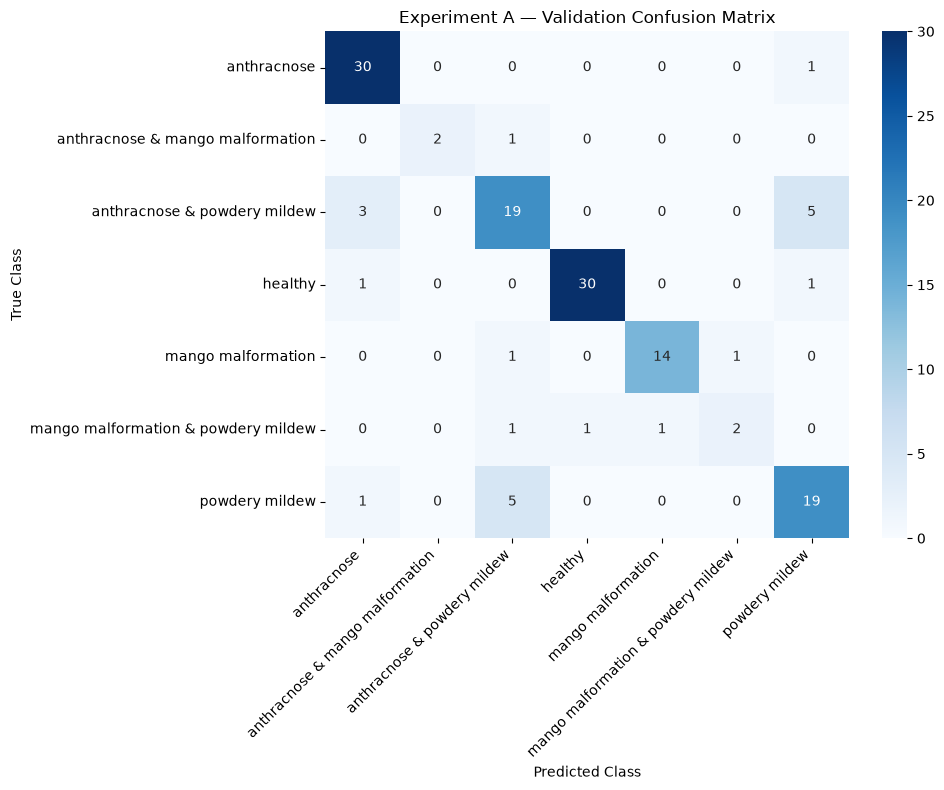

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_A = confusion_matrix(
    y_true_A,
    y_pred_A
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_A,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Experiment A — Validation Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import recall_score

per_class_recall = recall_score(
    y_true_A,
    y_pred_A,
    average=None
)

print("Per-class Recall:")
print()

for class_name, recall in zip(
    class_names,
    per_class_recall
):
    print(
        f"{class_name:40s} : {recall:.4f}"
    )

Per-class Recall:

anthracnose                              : 0.9677
anthracnose & mango malformation         : 0.6667
anthracnose & powdery mildew             : 0.7037
healthy                                  : 0.9375
mango malformation                       : 0.8750
mango malformation & powdery mildew      : 0.4000
powdery mildew                           : 0.7600


In [22]:
# ============================================
# VALIDATION & TEST CLASS DISTRIBUTION
# ============================================

import numpy as np

def get_class_counts(dataset, class_names):
    labels = []

    for images, batch_labels in dataset:
        labels.extend(batch_labels.numpy())

    labels = np.array(labels)

    counts = np.bincount(
        labels,
        minlength=len(class_names)
    )

    return counts


val_counts = get_class_counts(
    validation_ds,
    class_names
)

test_counts = get_class_counts(
    test_ds,
    class_names
)


print("=" * 80)
print("CLASS DISTRIBUTION")
print("=" * 80)

print(
    f"{'Class':45s}"
    f"{'Validation':>15s}"
    f"{'Test':>15s}"
)

print("-" * 80)

for i, name in enumerate(class_names):
    print(
        f"{name:45s}"
        f"{val_counts[i]:>15d}"
        f"{test_counts[i]:>15d}"
    )

print("-" * 80)

print(
    f"{'TOTAL':45s}"
    f"{val_counts.sum():>15d}"
    f"{test_counts.sum():>15d}"
)

W0000 00:00:1790104151.797047    1835 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


CLASS DISTRIBUTION
Class                                             Validation           Test
--------------------------------------------------------------------------------
anthracnose                                               31             32
anthracnose & mango malformation                           3              5
anthracnose & powdery mildew                              27             29
healthy                                                   32             34
mango malformation                                        16             18
mango malformation & powdery mildew                        5              6
powdery mildew                                            25             27
--------------------------------------------------------------------------------
TOTAL                                                    139            151


In [23]:
# ============================================
# LOAD BEST EXPERIMENT A MODEL
# ============================================

best_model_A = keras.models.load_model(
    os.path.join(
        MODEL_DIR,
        "experiment_A_baseline_best.keras"
    )
)

print("Best Experiment A model loaded.")

Best Experiment A model loaded.


In [25]:
# ============================================
# PREDICTIONS
# ============================================

# ---------- VALIDATION ----------

y_val_true = np.concatenate([
    labels.numpy()
    for images, labels in validation_ds
])

y_val_prob = best_model_A.predict(
    validation_ds,
    verbose=1
)

y_val_pred = np.argmax(
    y_val_prob,
    axis=1
)


# ---------- TEST ----------

y_test_true = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

y_test_prob = best_model_A.predict(
    test_ds,
    verbose=1
)

y_test_pred = np.argmax(
    y_test_prob,
    axis=1
)


print("Validation predictions:", len(y_val_pred))
print("Test predictions:", len(y_test_pred))

W0000 00:00:1790104250.728822    1835 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 41943296 bytes after encountering the first element of size 41943296 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1790104253.452363    1835 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 41943296 bytes after encountering the first element of size 41943296 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 301ms/step


W0000 00:00:1790104256.163121   11717 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 41943296 bytes after encountering the first element of size 41943296 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1790104256.166205    1835 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 41943296 bytes after encountering the first element of size 41943296 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
W0000 00:00:1790104259.128404    1835 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 41943296 bytes after encountering the first element of size 41943296 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step

E0000 00:00:1790104274.972868    2351 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790104282.400329    2351 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1790104287.146068    2351 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step 
Validation predictions: 139
Test predictions: 151


In [26]:
# ============================================
# VALIDATION CLASSIFICATION REPORT
# ============================================

print("=" * 80)
print("EXPERIMENT A — VALIDATION CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=class_names,
        digits=4
    )
)

print("Macro Precision:",
      precision_score(
          y_val_true,
          y_val_pred,
          average="macro"
      ))

print("Macro Recall:",
      recall_score(
          y_val_true,
          y_val_pred,
          average="macro"
      ))

print("Macro F1:",
      f1_score(
          y_val_true,
          y_val_pred,
          average="macro"
      ))

print("Weighted F1:",
      f1_score(
          y_val_true,
          y_val_pred,
          average="weighted"
      ))

EXPERIMENT A — VALIDATION CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.8571    0.9677    0.9091        31
   anthracnose & mango malformation     1.0000    0.6667    0.8000         3
       anthracnose & powdery mildew     0.7037    0.7037    0.7037        27
                            healthy     0.9677    0.9375    0.9524        32
                 mango malformation     0.9333    0.8750    0.9032        16
mango malformation & powdery mildew     0.6667    0.4000    0.5000         5
                     powdery mildew     0.7308    0.7600    0.7451        25

                           accuracy                         0.8345       139
                          macro avg     0.8371    0.7587    0.7876       139
                       weighted avg     0.8351    0.8345    0.8319       139

Macro Precision: 0.8370511038713805
Macro Recall: 0.7586589008363201
Macro F1: 0.787642772977552
Weigh

In [27]:
# ============================================
# TEST CLASSIFICATION REPORT
# ============================================

print("=" * 80)
print("EXPERIMENT A — TEST CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)

print("Macro Precision:",
      precision_score(
          y_test_true,
          y_test_pred,
          average="macro"
      ))

print("Macro Recall:",
      recall_score(
          y_test_true,
          y_test_pred,
          average="macro"
      ))

print("Macro F1:",
      f1_score(
          y_test_true,
          y_test_pred,
          average="macro"
      ))

print("Weighted F1:",
      f1_score(
          y_test_true,
          y_test_pred,
          average="weighted"
      ))

EXPERIMENT A — TEST CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                        anthracnose     0.8966    0.8125    0.8525        32
   anthracnose & mango malformation     1.0000    0.8000    0.8889         5
       anthracnose & powdery mildew     0.7931    0.7931    0.7931        29
                            healthy     0.9429    0.9706    0.9565        34
                 mango malformation     0.8571    1.0000    0.9231        18
mango malformation & powdery mildew     1.0000    0.8333    0.9091         6
                     powdery mildew     0.7500    0.7778    0.7636        27

                           accuracy                         0.8609       151
                          macro avg     0.8914    0.8553    0.8695       151
                       weighted avg     0.8637    0.8609    0.8605       151

Macro Precision: 0.8913793103448275
Macro Recall: 0.8553289706687272
Macro F1: 0.8695396126418321
Weighted F

In [28]:
# ============================================
# EXPERIMENT A — FINAL SUMMARY
# ============================================

val_accuracy = np.mean(
    y_val_true == y_val_pred
)

test_accuracy = np.mean(
    y_test_true == y_test_pred
)

val_macro_recall = recall_score(
    y_val_true,
    y_val_pred,
    average="macro"
)

test_macro_recall = recall_score(
    y_test_true,
    y_test_pred,
    average="macro"
)

val_macro_f1 = f1_score(
    y_val_true,
    y_val_pred,
    average="macro"
)

test_macro_f1 = f1_score(
    y_test_true,
    y_test_pred,
    average="macro"
)


print("=" * 65)
print("EXPERIMENT A — FINAL SUMMARY")
print("=" * 65)

print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Validation Macro F1 : {val_macro_f1:.4f}")
print(f"Validation Macro Recall : {val_macro_recall:.4f}")

print()

print(f"Test Accuracy       : {test_accuracy:.4f}")
print(f"Test Macro F1       : {test_macro_f1:.4f}")
print(f"Test Macro Recall   : {test_macro_recall:.4f}")

print("=" * 65)

EXPERIMENT A — FINAL SUMMARY
Validation Accuracy : 0.8345
Validation Macro F1 : 0.7876
Validation Macro Recall : 0.7587

Test Accuracy       : 0.8609
Test Macro F1       : 0.8695
Test Macro Recall   : 0.8553
